<a href="https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/process/automatedprocessdesign.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Automated process design in NeqSim

**Constrained design of a natural-gas conditioning train**

This tutorial turns a process flowsheet into a reproducible design study. NeqSim supplies
the thermodynamics and unit operations; Python supplies the parameter sweep, feasibility
logic, ranking, Pareto analysis, and reusable design report.

## Audience, prerequisites, and learning objectives

The notebook is written for process-engineering students and practicing engineers who know
basic Python and want to automate NeqSim studies. No previous optimization experience is
required.

By the end, you will be able to:

1. define a multicomponent natural gas with the SRK equation of state;
2. connect a stream, valve, cooler, separator, and compressor in `ProcessSystem`;
3. retrieve phase flows, duties, power, temperatures, and densities with explicit units;
4. close total, component, cooler-energy, and compressor-energy balances;
5. evaluate a grid of separator temperatures and pressures;
6. separate feasibility constraints from the ranking objective;
7. identify and interpret a Pareto frontier;
8. use NeqSim's process-automation facade for discovery and JSON snapshots; and
9. package the selected case as a deterministic engineering result.

## Preservation note and provenance

The previous catalog target contained only a Colab badge, an invalid `To be implemented`
code cell, and a literature link. It had **zero working examples and zero figures**.
This implementation preserves the intended automated-design topic and the original
literature reference in the references section.

All process inputs below are synthetic and reproducible. They are suitable for teaching,
not for equipment procurement or safety-critical design.

In [1]:
import importlib.util
import subprocess
import sys


required_packages = {
    "neqsim": "neqsim",
    "numpy": "numpy",
    "pandas": "pandas",
    "matplotlib": "matplotlib",
}
missing_packages = [
    package_name
    for module_name, package_name in required_packages.items()
    if importlib.util.find_spec(module_name) is None
]

if missing_packages:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "--upgrade",
            "--no-cache-dir",
            *missing_packages,
        ]
    )

In [2]:
import hashlib
import json
import platform
import subprocess
from importlib.metadata import version

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from matplotlib.patches import FancyArrowPatch
from matplotlib.patches import FancyBboxPatch
from neqsim import jneqsim


COLORS = {
    "blue": "#0072B2",
    "orange": "#D55E00",
    "green": "#009E73",
    "purple": "#CC79A7",
    "sky": "#56B4E9",
    "grey": "#666666",
}
plt.rcParams.update(
    {
        "figure.dpi": 115,
        "axes.grid": True,
        "grid.alpha": 0.25,
        "font.size": 10,
    }
)

java_version = subprocess.run(
    ["java", "-version"],
    capture_output=True,
    text=True,
    check=True,
).stderr.splitlines()[0]
runtime_table = pd.DataFrame(
    {
        "Runtime": ["NeqSim", "Python", "Java"],
        "Version": [
            version("neqsim"),
            platform.python_version(),
            java_version,
        ],
    }
)
display(runtime_table)

,Runtime,Version
0,NeqSim,3.16.0
1,Python,3.12.13
2,Java,"openjdk version ""17.0.19"" 2026-04-21"


## 1. Engineering design problem

A rich natural-gas stream arrives at 65 bara and 45 °C. A pressure-control valve lets the
stream down to a selectable cold-separator pressure. A cooler reaches a selectable
separator temperature. The separator removes hydrocarbon liquid, and the dry gas is
recompressed to 80 bara.

The design variables are:

- separator temperature $T_{sep}$ in °C; and
- separator pressure $p_{sep}$ in bara.

The design must recover useful liquid without excessive cooling duty or an excessive
compressor discharge temperature.

## 2. Governing balances

At steady state, total mass entering the separator equals the sum of gas and liquid mass:

$$
\dot{m}_{feed}=\dot{m}_{gas}+\dot{m}_{liquid}
$$

Here, every mass flow $\dot{m}$ is reported in kg/h. The same balance is checked for every
chemical component on a mol/s basis.

The cooler duty follows the steady-flow enthalpy change:

$$
\dot{Q}=\dot{m}(h_{out}-h_{in})
$$

NeqSim returns the cooler duty $\dot{Q}$ in W. Cooling gives a negative equipment duty, so
the notebook reports the positive cooling load $-\dot{Q}$ in kW. Specific enthalpy $h$ is
in J/kg and mass flow is in kg/s.

The compressor shaft power is checked independently from the stream enthalpy rise:

$$
\dot{W}=\dot{m}(h_{out}-h_{in})
$$

Shaft power $\dot{W}$ is in W. NeqSim calculates the real-gas isentropic state and applies
the specified isentropic efficiency $\eta_s$. The equation above is an energy balance, not
an ideal-gas shortcut.

## 3. Feasibility and ranking

A case is feasible when all four screening constraints hold:

- liquid recovery is at least 3.0 wt% of feed;
- compressor outlet temperature is no more than 95 °C;
- cooling load is no more than 1,600 kW; and
- compressor power is no more than 2,500 kW.

Feasible cases are ranked by equivalent electric demand:

$$
P_{eq}=P_{comp}+\frac{Q_{cool}}{COP}
$$

$P_{eq}$, compressor power $P_{comp}$, and cooling load $Q_{cool}$ are in kW. The assumed
coefficient of performance is $COP=3.0$. This transparent objective is a teaching choice,
not an economic optimum. Project work should add capital cost, utility prices, reliability,
turndown, uncertainty, and equipment maps.

In [3]:
component_mole_fractions = {
    "nitrogen": 0.020,
    "CO2": 0.015,
    "methane": 0.795,
    "ethane": 0.080,
    "propane": 0.045,
    "i-butane": 0.015,
    "n-butane": 0.015,
    "i-pentane": 0.005,
    "n-pentane": 0.005,
    "n-hexane": 0.005,
}
design_basis = {
    "feed_temperature_c": 45.0,
    "feed_pressure_bara": 65.0,
    "feed_mass_flow_kg_s": 10.0,
    "export_pressure_bara": 80.0,
    "compressor_isentropic_efficiency": 0.78,
    "mixing_rule": "classic",
    "minimum_liquid_recovery_wt_percent": 3.0,
    "maximum_discharge_temperature_c": 95.0,
    "maximum_cooling_load_kw": 1600.0,
    "maximum_compressor_power_kw": 2500.0,
    "cooling_coefficient_of_performance": 3.0,
}

composition_table = pd.DataFrame(
    {
        "Component": component_mole_fractions.keys(),
        "Mole fraction [-]": component_mole_fractions.values(),
    }
)
design_basis_table = pd.DataFrame(
    [
        ("Feed temperature", 45.0, "°C"),
        ("Feed pressure", 65.0, "bara"),
        ("Feed mass flow", 10.0, "kg/s"),
        ("Export pressure", 80.0, "bara"),
        ("Compressor efficiency", 0.78, "-"),
        ("Minimum liquid recovery", 3.0, "wt%"),
        ("Maximum discharge temperature", 95.0, "°C"),
        ("Maximum cooling load", 1600.0, "kW"),
        ("Maximum compressor power", 2500.0, "kW"),
        ("Cooling coefficient of performance", 3.0, "-"),
    ],
    columns=["Quantity", "Value", "Unit"],
)

display(composition_table)
display(design_basis_table)

,Component,Mole fraction [-]
0,nitrogen,0.020
1,CO2,0.015
2,methane,0.795
3,ethane,0.080
4,propane,0.045
5,i-butane,0.015
6,n-butane,0.015
7,i-pentane,0.005
8,n-pentane,0.005
9,n-hexane,0.005


,Quantity,Value,Unit
0,Feed temperature,45.00,°C
1,Feed pressure,65.00,bara
2,Feed mass flow,10.00,kg/s
3,Export pressure,80.00,bara
4,Compressor efficiency,0.78,-
5,Minimum liquid recovery,3.00,wt%
6,Maximum discharge temperature,95.00,°C
7,Maximum cooling load,1600.00,kW
8,Maximum compressor power,2500.00,kW
9,Cooling coefficient of performance,3.00,-


In [4]:
case_definition = {
    "composition": component_mole_fractions,
    "design_basis": design_basis,
}
canonical_case_json = json.dumps(
    case_definition,
    sort_keys=True,
    separators=(",", ":"),
)
case_fingerprint = hashlib.sha256(
    canonical_case_json.encode("utf-8")
).hexdigest()
composition_sum = sum(component_mole_fractions.values())

print(f"Case fingerprint: {case_fingerprint}")
print(f"Composition sum: {composition_sum:.12f}")

Case fingerprint: 45f23a5230ab52a2b4e6e769ff35ac83d03e633d1cfd69deebcc334f6b7e21c7
Composition sum: 1.000000000000


## 4. Model and API choices

The Soave-Redlich-Kwong (SRK) equation of state with the classic mixing rule is a common
screening model for natural-gas processing. Multiphase checking is enabled because the
objective depends on hydrocarbon condensation. The synthetic C1–C6 mixture is fully
specified on a mole-fraction basis.

NeqSim objects used in the workflow are:

- `SystemSrkEos` for the thermodynamic fluid;
- `Stream` for named material streams;
- `ThrottlingValve` for an isenthalpic pressure let-down;
- `Cooler` for a specified outlet temperature;
- `Separator` for equilibrium gas-liquid separation;
- `Compressor` for real-gas recompression; and
- `ProcessSystem` for ordered flowsheet execution and automation access.

In [5]:
SystemSrkEos = jneqsim.thermo.system.SystemSrkEos
ThermodynamicOperations = (
    jneqsim.thermodynamicoperations.ThermodynamicOperations
)


def build_feed_fluid():
    fluid = SystemSrkEos(
        design_basis["feed_temperature_c"] + 273.15,
        design_basis["feed_pressure_bara"],
    )

    for component_name, mole_fraction in component_mole_fractions.items():
        fluid.addComponent(component_name, mole_fraction)

    fluid.setMixingRule(design_basis["mixing_rule"])
    fluid.setMultiPhaseCheck(True)
    fluid.setTotalFlowRate(
        design_basis["feed_mass_flow_kg_s"],
        "kg/sec",
    )
    operations = ThermodynamicOperations(fluid)
    operations.TPflash()
    fluid.init(0)
    fluid.init(1)
    fluid.initPhysicalProperties()
    return fluid

In [6]:
feed_fluid = build_feed_fluid()
feed_property_table = pd.DataFrame(
    [
        {
            "Temperature [°C]": feed_fluid.getTemperature("C"),
            "Pressure [bara]": feed_fluid.getPressure("bara"),
            "Molar mass [kg/mol]": feed_fluid.getMolarMass("kg/mol"),
            "Density [kg/m³]": feed_fluid.getDensity("kg/m3"),
            "Enthalpy [kJ/kg]": (
                feed_fluid.getEnthalpy("J/kg") / 1000.0
            ),
        }
    ]
)
display(feed_property_table)

,Temperature [°C],Pressure [bara],Molar mass [kg/mol],Density [kg/m³],Enthalpy [kJ/kg]
0,45.0,65.0,0.021261,61.252809,74.630352


The feed flash establishes a reproducible thermodynamic state before any process equipment
is created. The downstream valve and cooler may cross the phase boundary, so each design
case must be solved rather than estimated by a fixed recovery factor.

## 5. Process topology

The diagram is a model map, not a piping-and-instrumentation diagram. Named streams and unit
operations make the workflow inspectable and reusable in a larger process model.

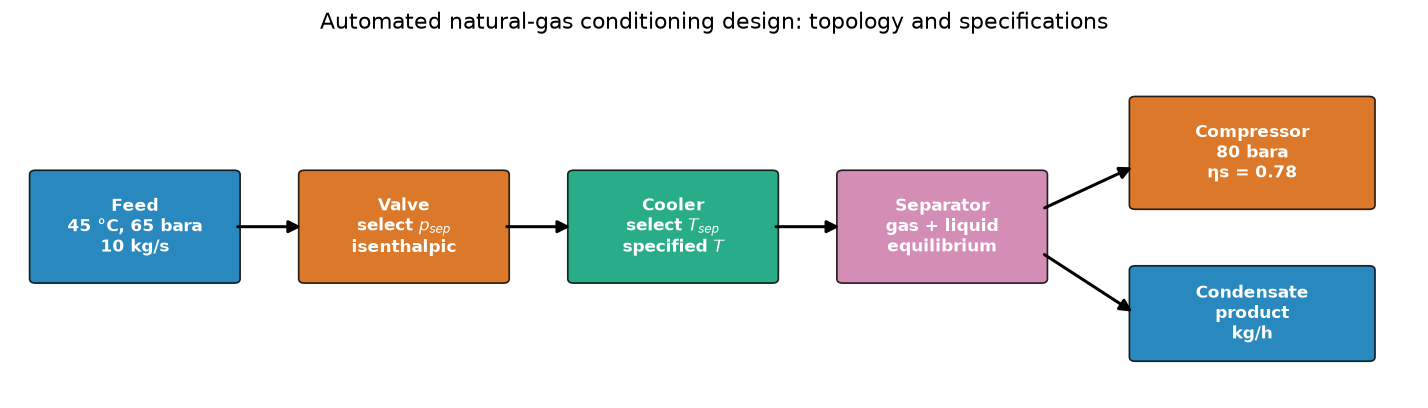

In [7]:
figure, axis = plt.subplots(figsize=(12.0, 3.5))
axis.set_xlim(0.0, 12.0)
axis.set_ylim(0.0, 4.0)
axis.axis("off")

unit_boxes = [
    (0.2, 1.35, 1.7, 1.2, "Feed\n45 °C, 65 bara\n10 kg/s", "blue"),
    (2.5, 1.35, 1.7, 1.2, "Valve\nselect $p_{sep}$\nisenthalpic", "orange"),
    (4.8, 1.35, 1.7, 1.2, "Cooler\nselect $T_{sep}$\nspecified $T$", "green"),
    (7.1, 1.35, 1.7, 1.2, "Separator\ngas + liquid\nequilibrium", "purple"),
    (9.6, 2.20, 2.0, 1.2, "Compressor\n80 bara\nηs = 0.78", "orange"),
    (9.6, 0.45, 2.0, 1.0, "Condensate\nproduct\nkg/h", "blue"),
]

for x_value, y_value, width, height, label, colour_key in unit_boxes:
    box = FancyBboxPatch(
        (x_value, y_value),
        width,
        height,
        boxstyle="round,pad=0.05",
        facecolor=COLORS[colour_key],
        edgecolor="black",
        alpha=0.84,
    )
    axis.add_patch(box)
    axis.text(
        x_value + width / 2.0,
        y_value + height / 2.0,
        label,
        ha="center",
        va="center",
        color="white",
        fontweight="bold",
    )

arrow_pairs = [
    ((1.9, 1.95), (2.5, 1.95)),
    ((4.2, 1.95), (4.8, 1.95)),
    ((6.5, 1.95), (7.1, 1.95)),
    ((8.8, 2.15), (9.6, 2.65)),
    ((8.8, 1.65), (9.6, 0.95)),
]

for start_point, end_point in arrow_pairs:
    axis.add_patch(
        FancyArrowPatch(
            start_point,
            end_point,
            arrowstyle="-|>",
            mutation_scale=15,
            linewidth=1.8,
            color="black",
        )
    )

axis.set_title(
    "Automated natural-gas conditioning design: topology and specifications",
    fontsize=13,
    pad=12,
)
plt.tight_layout()
plt.show()

## 6. A reusable NeqSim case evaluator

Each evaluation builds a fresh fluid and flowsheet. That makes a design point independent
of the order in which cases are run and prevents hidden state from contaminating the
results. The function returns both a flat result dictionary for analysis and the NeqSim
objects needed for inspection or integration.

In [8]:
Stream = jneqsim.process.equipment.stream.Stream
ThrottlingValve = jneqsim.process.equipment.valve.ThrottlingValve
Cooler = jneqsim.process.equipment.heatexchanger.Cooler
Separator = jneqsim.process.equipment.separator.Separator
Compressor = jneqsim.process.equipment.compressor.Compressor
ProcessSystem = jneqsim.process.processmodel.ProcessSystem


def simulate_design(separator_temperature_c, separator_pressure_bara):
    fluid = build_feed_fluid()
    case_name = (
        f"T{separator_temperature_c:+.0f}_"
        f"P{separator_pressure_bara:.0f}"
    )
    feed = Stream(f"{case_name} feed", fluid)
    valve = ThrottlingValve(f"{case_name} inlet valve", feed)
    valve.setOutletPressure(separator_pressure_bara, "bara")
    valve.setPercentValveOpening(100.0)

    cooler = Cooler(f"{case_name} feed cooler", valve.getOutletStream())
    cooler.setOutTemperature(separator_temperature_c, "C")
    separator = Separator(
        f"{case_name} cold separator",
        cooler.getOutletStream(),
    )
    compressor = Compressor(
        f"{case_name} export compressor",
        separator.getGasOutStream(),
    )
    compressor.setOutletPressure(
        design_basis["export_pressure_bara"],
        "bara",
    )
    compressor.setIsentropicEfficiency(
        design_basis["compressor_isentropic_efficiency"]
    )

    process = ProcessSystem()

    for unit_operation in [
        feed,
        valve,
        cooler,
        separator,
        compressor,
    ]:
        process.add(unit_operation)

    process.run()

    gas_product = separator.getGasOutStream()
    liquid_product = separator.getLiquidOutStream()
    cooler_inlet = valve.getOutletStream()
    cooler_outlet = cooler.getOutletStream()
    compressor_outlet = compressor.getOutletStream()
    cooler_enthalpy_change_w = cooler_outlet.getFlowRate(
        "kg/sec"
    ) * (
        cooler_outlet.getFluid().getEnthalpy("J/kg")
        - cooler_inlet.getFluid().getEnthalpy("J/kg")
    )
    compressor_enthalpy_change_w = compressor_outlet.getFlowRate(
        "kg/sec"
    ) * (
        compressor_outlet.getFluid().getEnthalpy("J/kg")
        - gas_product.getFluid().getEnthalpy("J/kg")
    )
    feed_flow_kg_h = feed.getFlowRate("kg/hr")
    gas_flow_kg_h = gas_product.getFlowRate("kg/hr")
    liquid_flow_kg_h = liquid_product.getFlowRate("kg/hr")
    cooling_load_kw = -cooler.getDuty() / 1000.0
    compressor_power_kw = compressor.getPower("W") / 1000.0
    equivalent_power_kw = compressor_power_kw + (
        cooling_load_kw
        / design_basis["cooling_coefficient_of_performance"]
    )
    result = {
        "Separator temperature [°C]": separator_temperature_c,
        "Separator pressure [bara]": separator_pressure_bara,
        "Feed flow [kg/h]": feed_flow_kg_h,
        "Gas flow [kg/h]": gas_flow_kg_h,
        "Liquid flow [kg/h]": liquid_flow_kg_h,
        "Liquid recovery [wt%]": (
            100.0 * liquid_flow_kg_h / feed_flow_kg_h
        ),
        "Cooling load [kW]": cooling_load_kw,
        "Compressor power [kW]": compressor_power_kw,
        "Equivalent power [kW]": equivalent_power_kw,
        "Compressor outlet [°C]": (
            compressor_outlet.getTemperature("C")
        ),
        "Gas density [kg/m³]": (
            gas_product.getFluid().getDensity("kg/m3")
        ),
        "Liquid density [kg/m³]": (
            liquid_product.getFluid().getDensity("kg/m3")
        ),
        "Mass residual [kg/h]": (
            feed_flow_kg_h - gas_flow_kg_h - liquid_flow_kg_h
        ),
        "Cooler energy residual [W]": (
            cooler.getDuty() - cooler_enthalpy_change_w
        ),
        "Compressor energy residual [W]": (
            compressor.getPower("W")
            - compressor_enthalpy_change_w
        ),
    }
    objects = {
        "process": process,
        "feed": feed,
        "valve": valve,
        "cooler": cooler,
        "separator": separator,
        "gas product": gas_product,
        "liquid product": liquid_product,
        "compressor": compressor,
    }
    return {
        "result": result,
        "objects": objects,
    }

In [9]:
base_case = simulate_design(
    separator_temperature_c=0.0,
    separator_pressure_bara=35.0,
)
base_result = pd.DataFrame([base_case["result"]])
base_columns = [
    "Separator temperature [°C]",
    "Separator pressure [bara]",
    "Gas flow [kg/h]",
    "Liquid flow [kg/h]",
    "Liquid recovery [wt%]",
    "Cooling load [kW]",
    "Compressor power [kW]",
    "Equivalent power [kW]",
    "Compressor outlet [°C]",
]
display(base_result[base_columns].round(6))

,Separator temperature [°C],Separator pressure [bara],Gas flow [kg/h],Liquid flow [kg/h],Liquid recovery [wt%],Cooling load [kW],Compressor power [kW],Equivalent power [kW],Compressor outlet [°C]
0,0.0,35.0,32682.562646,3317.437354,9.215104,940.620459,1048.985874,1362.526027,68.12545


The base case is intentionally only a reference point. It demonstrates that the process
converges and produces both gas and liquid. Automated design becomes useful because colder
or lower-pressure separation can improve recovery while increasing refrigeration or
recompression demand.

## 7. Conservation checks

A flowsheet is not accepted merely because it runs. Total and component balances are
calculated at the separator boundary. The component balance uses the total stream molar
flow multiplied by each component's overall mole fraction.

In [10]:
component_names = list(component_mole_fractions)


def component_molar_rates(stream_object):
    stream_fluid = stream_object.getFluid()
    total_molar_rate = stream_object.getFlowRate("mole/sec")
    return np.asarray(
        [
            total_molar_rate
            * stream_fluid.getComponent(component_name).getz()
            for component_name in component_names
        ]
    )


base_objects = base_case["objects"]
feed_component_rates = component_molar_rates(base_objects["feed"])
gas_component_rates = component_molar_rates(
    base_objects["gas product"]
)
liquid_component_rates = component_molar_rates(
    base_objects["liquid product"]
)
component_residuals = (
    feed_component_rates
    - gas_component_rates
    - liquid_component_rates
)
component_balance_table = pd.DataFrame(
    {
        "Component": component_names,
        "Feed [mol/s]": feed_component_rates,
        "Gas [mol/s]": gas_component_rates,
        "Liquid [mol/s]": liquid_component_rates,
        "Residual [mol/s]": component_residuals,
    }
)
display(component_balance_table)

,Component,Feed [mol/s],Gas [mol/s],Liquid [mol/s],Residual [mol/s]
0,nitrogen,9.407050,9.379323,0.027727,2.058734e-11
1,CO2,7.055288,6.895662,0.159626,7.005591e-12
2,methane,373.930242,370.523939,3.406303,6.783267e-10
3,ethane,37.628200,35.800762,1.827439,-2.193912e-11
4,propane,21.165863,17.984434,3.181429,-1.431695e-10
5,i-butane,7.055288,4.971311,2.083977,-1.099054e-10
6,n-butane,7.055288,4.398780,2.656508,-1.446909e-10
7,i-pentane,2.351763,0.951562,1.400201,-7.950018e-11
8,n-pentane,2.351763,0.795735,1.556028,-8.896750e-11
9,n-hexane,2.351763,0.321126,2.030636,-1.178018e-10


In [11]:
base_audit_table = pd.DataFrame(
    [
        {
            "Check": "Total mass balance",
            "Residual": base_case["result"][
                "Mass residual [kg/h]"
            ],
            "Unit": "kg/h",
        },
        {
            "Check": "Maximum component balance",
            "Residual": np.max(np.abs(component_residuals)),
            "Unit": "mol/s",
        },
        {
            "Check": "Cooler energy balance",
            "Residual": base_case["result"][
                "Cooler energy residual [W]"
            ],
            "Unit": "W",
        },
        {
            "Check": "Compressor energy balance",
            "Residual": base_case["result"][
                "Compressor energy residual [W]"
            ],
            "Unit": "W",
        },
    ]
)
display(base_audit_table)

,Check,Residual,Unit
0,Total mass balance,-1.163153e-07,kg/h
1,Maximum component balance,6.783267e-10,mol/s
2,Cooler energy balance,0.000000e+00,W
3,Compressor energy balance,2.328306e-10,W


Residuals should be close to floating-point precision compared with flows of 10 kg/s and
hundreds of mol/s. These checks validate the bookkeeping and unit conversions used by the
notebook; they do not validate an equation of state against laboratory data.

## 8. Base-case state profile

A process profile helps distinguish the pressure let-down, refrigeration step, phase split,
and recompression. Temperature and pressure are retrieved from the named NeqSim streams
after the complete `ProcessSystem` has run.

In [12]:
profile_streams = [
    ("Feed", base_objects["feed"]),
    ("After valve", base_objects["valve"].getOutletStream()),
    ("After cooler", base_objects["cooler"].getOutletStream()),
    ("Gas product", base_objects["gas product"]),
    ("Export gas", base_objects["compressor"].getOutletStream()),
]
state_profile = pd.DataFrame(
    [
        {
            "Location": location_name,
            "Temperature [°C]": stream_object.getTemperature("C"),
            "Pressure [bara]": stream_object.getPressure("bara"),
            "Mass flow [kg/h]": stream_object.getFlowRate("kg/hr"),
        }
        for location_name, stream_object in profile_streams
    ]
)
display(state_profile.round(6))

,Location,Temperature [°C],Pressure [bara],Mass flow [kg/h]
0,Feed,45.000000,65.0,36000.000000
1,After valve,29.403462,35.0,36000.000000
2,After cooler,0.000000,35.0,36000.000000
3,Gas product,0.000000,35.0,32682.562646
4,Export gas,68.125450,80.0,32682.562646


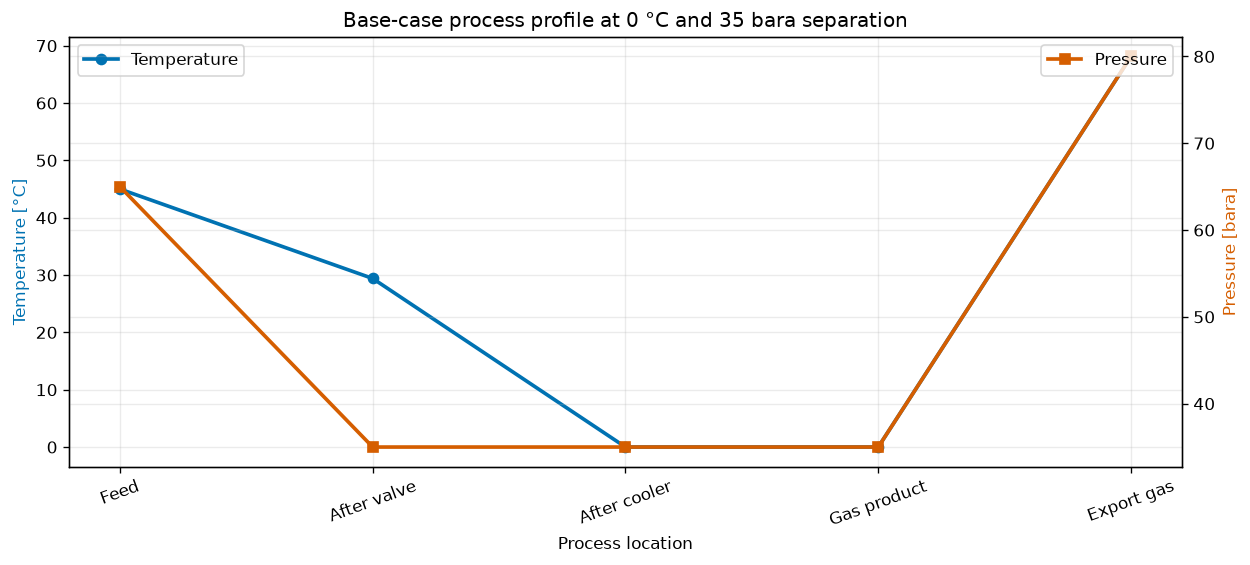

In [13]:
locations = state_profile["Location"].tolist()
x_positions = np.arange(len(locations))
figure, temperature_axis = plt.subplots(figsize=(10.5, 4.8))
pressure_axis = temperature_axis.twinx()

temperature_axis.plot(
    x_positions,
    state_profile["Temperature [°C]"],
    marker="o",
    linewidth=2.2,
    color=COLORS["blue"],
    label="Temperature",
)
pressure_axis.plot(
    x_positions,
    state_profile["Pressure [bara]"],
    marker="s",
    linewidth=2.2,
    color=COLORS["orange"],
    label="Pressure",
)
temperature_axis.set_xticks(x_positions, locations, rotation=20)
temperature_axis.set_xlabel("Process location")
temperature_axis.set_ylabel("Temperature [°C]", color=COLORS["blue"])
pressure_axis.set_ylabel("Pressure [bara]", color=COLORS["orange"])
temperature_axis.set_title(
    "Base-case process profile at 0 °C and 35 bara separation"
)
temperature_axis.legend(loc="upper left")
pressure_axis.legend(loc="upper right")
plt.tight_layout()
plt.show()

The profile confirms the intended sequence: valve pressure reduction, cooling to the
separator setpoint, equilibrium separation, and gas recompression. A discharge temperature
limit is included because it can become the active constraint at low separator pressure.

## 9. Automated design-space evaluation

The grid covers separator temperatures from -15 to 15 °C and pressures from 25 to 50 bara.
Forty-two independent NeqSim flowsheets are solved. A regular grid is transparent, robust,
and useful for visualizing multiple local trade-offs before applying a more sophisticated
optimizer.

In [14]:
separator_temperatures_c = np.arange(-15.0, 15.1, 5.0)
separator_pressures_bara = np.arange(25.0, 50.1, 5.0)
design_rows = []

for separator_temperature_c in separator_temperatures_c:
    for separator_pressure_bara in separator_pressures_bara:
        design_case = simulate_design(
            separator_temperature_c=float(
                separator_temperature_c
            ),
            separator_pressure_bara=float(
                separator_pressure_bara
            ),
        )
        design_rows.append(design_case["result"])

design_space = pd.DataFrame(design_rows)
print(f"Evaluated {len(design_space)} independent NeqSim designs.")
display(design_space.head().round(6))

Evaluated 42 independent NeqSim designs.


,Separator temperature [°C],Separator pressure [bara],Feed flow [kg/h],Gas flow [kg/h],Liquid flow [kg/h],Liquid recovery [wt%],Cooling load [kW],Compressor power [kW],Equivalent power [kW],Compressor outlet [°C],Gas density [kg/m³],Liquid density [kg/m³],Mass residual [kg/h],Cooler energy residual [W],Compressor energy residual [W]
0,-15.0,25.0,36000.0,31481.804387,4518.195613,12.550543,1241.762935,1466.266486,1880.187465,80.691758,25.614951,580.564093,-0.0,0.0,-0.0
1,-15.0,30.0,36000.0,30935.436027,5064.563973,14.068233,1361.808694,1175.964997,1629.901229,65.369575,31.203379,566.555884,-0.0,0.0,0.0
2,-15.0,35.0,36000.0,30466.887359,5533.112641,15.369757,1473.055716,944.874640,1435.893213,52.336766,37.040793,553.263356,-0.0,-0.0,0.0
3,-15.0,40.0,36000.0,30057.318428,5942.681572,16.507449,1577.919457,756.289676,1282.262828,41.022401,43.161995,540.393225,0.0,0.0,0.0
4,-15.0,45.0,36000.0,29694.275324,6305.724676,17.515902,1678.078781,599.675057,1159.034651,31.056754,49.604844,527.752602,-0.0,0.0,-0.0


In [15]:
design_space["Recovery constraint"] = (
    design_space["Liquid recovery [wt%]"]
    >= design_basis["minimum_liquid_recovery_wt_percent"]
)
design_space["Temperature constraint"] = (
    design_space["Compressor outlet [°C]"]
    <= design_basis["maximum_discharge_temperature_c"]
)
design_space["Cooling constraint"] = (
    design_space["Cooling load [kW]"]
    <= design_basis["maximum_cooling_load_kw"]
)
design_space["Power constraint"] = (
    design_space["Compressor power [kW]"]
    <= design_basis["maximum_compressor_power_kw"]
)
constraint_columns = [
    "Recovery constraint",
    "Temperature constraint",
    "Cooling constraint",
    "Power constraint",
]
design_space["Feasible"] = design_space[
    constraint_columns
].all(axis=1)

feasible_designs = design_space[design_space["Feasible"]].copy()
feasible_designs = feasible_designs.sort_values(
    "Equivalent power [kW]"
)
display(
    feasible_designs[
        [
            "Separator temperature [°C]",
            "Separator pressure [bara]",
            "Liquid recovery [wt%]",
            "Cooling load [kW]",
            "Compressor power [kW]",
            "Equivalent power [kW]",
            "Compressor outlet [°C]",
        ]
    ].head(10).round(6)
)

,Separator temperature [°C],Separator pressure [bara],Liquid recovery [wt%],Cooling load [kW],Compressor power [kW],Equivalent power [kW],Compressor outlet [°C]
41,15.0,50.0,5.447618,690.284765,592.957432,823.052354,53.558387
35,10.0,50.0,7.413260,863.313186,573.073347,860.844409,48.406237
29,5.0,50.0,9.470303,1039.580127,552.823677,899.350386,43.229513
23,0.0,50.0,11.609261,1218.976533,532.206121,938.531632,38.024082
40,15.0,45.0,4.993997,609.026702,748.654580,951.663481,62.439404
17,-5.0,50.0,13.818614,1401.344052,511.212802,978.327486,32.785248
34,10.0,45.0,6.886491,779.520847,724.911246,984.751529,57.290114
28,5.0,45.0,8.871535,953.310302,700.735000,1018.505101,52.115299
11,-10.0,50.0,16.089205,1586.582266,489.822008,1018.682763,27.508162
22,0.0,45.0,10.939681,1130.272946,676.128506,1052.886155,46.910228


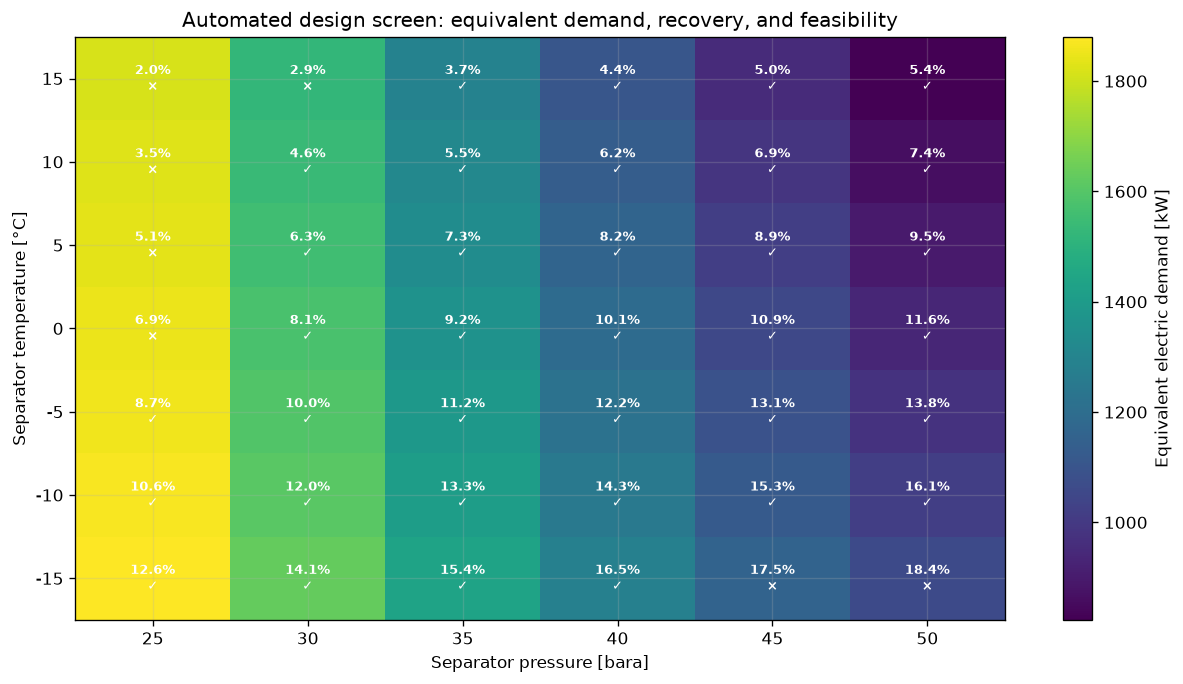

In [16]:
equivalent_power_grid = design_space.pivot(
    index="Separator temperature [°C]",
    columns="Separator pressure [bara]",
    values="Equivalent power [kW]",
)
recovery_grid = design_space.pivot(
    index="Separator temperature [°C]",
    columns="Separator pressure [bara]",
    values="Liquid recovery [wt%]",
)
feasible_grid = design_space.pivot(
    index="Separator temperature [°C]",
    columns="Separator pressure [bara]",
    values="Feasible",
)

figure, axis = plt.subplots(figsize=(10.5, 5.8))
image = axis.imshow(
    equivalent_power_grid.to_numpy(),
    aspect="auto",
    origin="lower",
    cmap="viridis",
)
colour_bar = figure.colorbar(image, ax=axis)
colour_bar.set_label("Equivalent electric demand [kW]")
axis.set_xticks(
    np.arange(len(equivalent_power_grid.columns)),
    [
        f"{pressure_value:.0f}"
        for pressure_value in equivalent_power_grid.columns
    ],
)
axis.set_yticks(
    np.arange(len(equivalent_power_grid.index)),
    [
        f"{temperature_value:.0f}"
        for temperature_value in equivalent_power_grid.index
    ],
)
axis.set_xlabel("Separator pressure [bara]")
axis.set_ylabel("Separator temperature [°C]")
axis.set_title(
    "Automated design screen: equivalent demand, recovery, and feasibility"
)

for row_index in range(len(equivalent_power_grid.index)):
    for column_index in range(len(equivalent_power_grid.columns)):
        recovery_value = recovery_grid.iloc[
            row_index,
            column_index,
        ]
        feasible_value = feasible_grid.iloc[
            row_index,
            column_index,
        ]
        marker = "✓" if feasible_value else "×"
        axis.text(
            column_index,
            row_index,
            f"{recovery_value:.1f}%\n{marker}",
            ha="center",
            va="center",
            color="white",
            fontsize=8,
            fontweight="bold",
        )

plt.tight_layout()
plt.show()

Every annotation shows liquid recovery in wt%. A check mark means all four constraints pass;
a cross means at least one fails. The color scale ranks energy demand but does not override
feasibility. This prevents an infeasible low-energy point from being presented as the
selected design.

## 10. Pareto trade-off

A point is Pareto efficient when no other feasible point has both lower equivalent power
and at least as much liquid recovery. The frontier shows the extra energy associated with
progressively higher recovery without hiding the discrete design choices.

In [17]:
def find_pareto_frontier(feasible_table):
    ordered = feasible_table.sort_values(
        [
            "Equivalent power [kW]",
            "Liquid recovery [wt%]",
        ],
        ascending=[True, False],
    )
    pareto_indices = []
    best_recovery = -np.inf

    for row_index, row in ordered.iterrows():
        recovery = row["Liquid recovery [wt%]"]

        if recovery > best_recovery + 1.0e-12:
            pareto_indices.append(row_index)
            best_recovery = recovery

    return ordered.loc[pareto_indices].copy()


pareto_frontier = find_pareto_frontier(feasible_designs)
display(
    pareto_frontier[
        [
            "Separator temperature [°C]",
            "Separator pressure [bara]",
            "Liquid recovery [wt%]",
            "Equivalent power [kW]",
        ]
    ].round(6)
)

,Separator temperature [°C],Separator pressure [bara],Liquid recovery [wt%],Equivalent power [kW]
41,15.0,50.0,5.447618,823.052354
35,10.0,50.0,7.413260,860.844409
29,5.0,50.0,9.470303,899.350386
23,0.0,50.0,11.609261,938.531632
17,-5.0,50.0,13.818614,978.327486
11,-10.0,50.0,16.089205,1018.682763
3,-15.0,40.0,16.507449,1282.262828


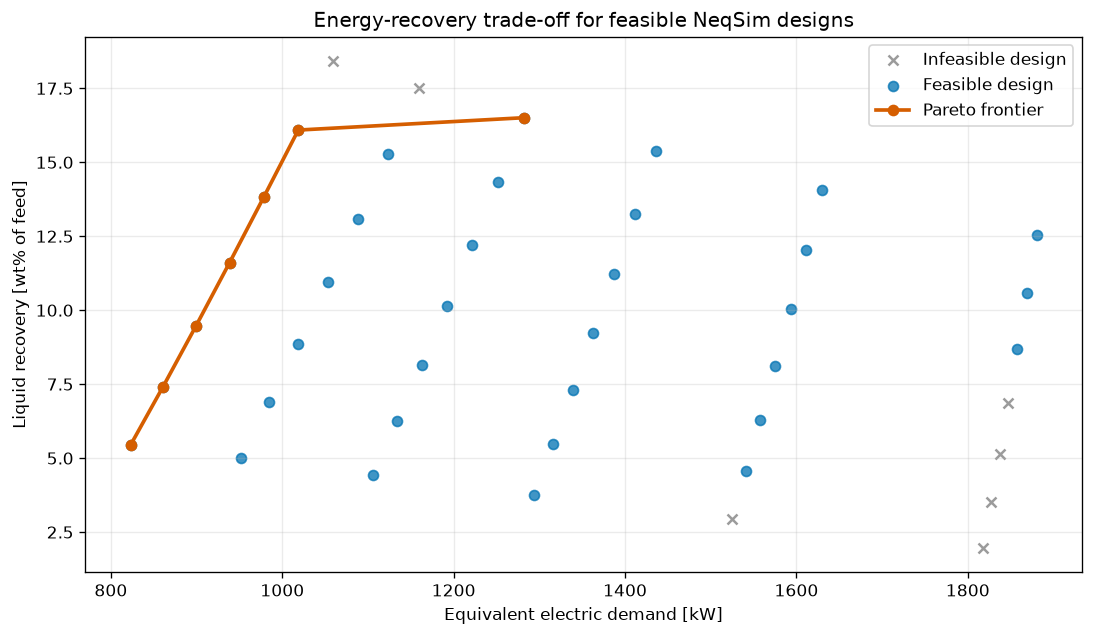

In [18]:
figure, axis = plt.subplots(figsize=(9.2, 5.4))
infeasible_designs = design_space[~design_space["Feasible"]]

axis.scatter(
    infeasible_designs["Equivalent power [kW]"],
    infeasible_designs["Liquid recovery [wt%]"],
    color=COLORS["grey"],
    marker="x",
    alpha=0.65,
    label="Infeasible design",
)
axis.scatter(
    feasible_designs["Equivalent power [kW]"],
    feasible_designs["Liquid recovery [wt%]"],
    color=COLORS["blue"],
    alpha=0.75,
    label="Feasible design",
)
axis.plot(
    pareto_frontier["Equivalent power [kW]"],
    pareto_frontier["Liquid recovery [wt%]"],
    color=COLORS["orange"],
    marker="o",
    linewidth=2.2,
    label="Pareto frontier",
)
axis.set_xlabel("Equivalent electric demand [kW]")
axis.set_ylabel("Liquid recovery [wt% of feed]")
axis.set_title(
    "Energy-recovery trade-off for feasible NeqSim designs"
)
axis.legend()
plt.tight_layout()
plt.show()

The minimum-energy feasible design is not automatically the most valuable design. The
Pareto curve lets an engineer quantify how much equivalent power is required for the next
increment of liquid recovery before applying economic prices or capacity constraints.

## 11. One-factor sensitivity

Holding separator temperature at 0 °C isolates the effect of pressure. Lower pressure can
enhance flashing and recovery but increases the compressor pressure ratio. The expected
monotonic power trend is used as a numerical and physical check.

In [19]:
pressure_sensitivity = design_space[
    design_space["Separator temperature [°C]"] == 0.0
].sort_values("Separator pressure [bara]")
display(
    pressure_sensitivity[
        [
            "Separator pressure [bara]",
            "Liquid recovery [wt%]",
            "Compressor power [kW]",
            "Compressor outlet [°C]",
        ]
    ].round(6)
)

,Separator pressure [bara],Liquid recovery [wt%],Compressor power [kW],Compressor outlet [°C]
18,25.0,6.851078,1604.823263,96.254854
19,30.0,8.125908,1296.198180,81.067114
20,35.0,9.215104,1048.985874,68.125450
21,40.0,10.146255,845.940310,56.861450
22,45.0,10.939681,676.128506,46.910228
23,50.0,11.609261,532.206121,38.024082


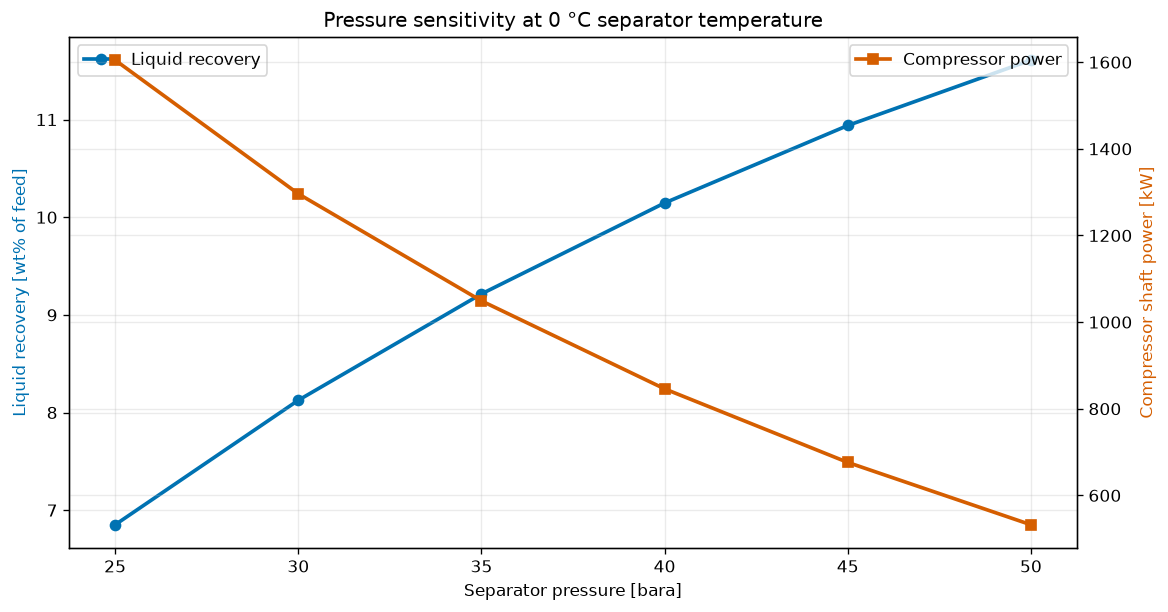

In [20]:
figure, recovery_axis = plt.subplots(figsize=(9.8, 5.2))
power_axis = recovery_axis.twinx()

recovery_axis.plot(
    pressure_sensitivity["Separator pressure [bara]"],
    pressure_sensitivity["Liquid recovery [wt%]"],
    marker="o",
    linewidth=2.2,
    color=COLORS["blue"],
    label="Liquid recovery",
)
power_axis.plot(
    pressure_sensitivity["Separator pressure [bara]"],
    pressure_sensitivity["Compressor power [kW]"],
    marker="s",
    linewidth=2.2,
    color=COLORS["orange"],
    label="Compressor power",
)
recovery_axis.set_xlabel("Separator pressure [bara]")
recovery_axis.set_ylabel(
    "Liquid recovery [wt% of feed]",
    color=COLORS["blue"],
)
power_axis.set_ylabel(
    "Compressor shaft power [kW]",
    color=COLORS["orange"],
)
recovery_axis.set_title(
    "Pressure sensitivity at 0 °C separator temperature"
)
recovery_axis.legend(loc="upper left")
power_axis.legend(loc="upper right")
plt.tight_layout()
plt.show()

The recompression power should fall as separator pressure rises because the pressure ratio
decreases. Recovery may move in the opposite direction. This opposing trend is the physical
reason that a constrained design search is more informative than selecting the coldest or
lowest-pressure point.

## 12. Final application: select, rerun, inspect, and export

The final workflow selects the feasible design with minimum equivalent electric demand,
reruns it as a fresh NeqSim process, verifies the result, and accesses the process
automation facade. The facade provides unit discovery and a structured snapshot suitable
for dashboards, agents, digital twins, or a larger design pipeline.

In [21]:
selected_row = feasible_designs.iloc[0]
selected_case = simulate_design(
    separator_temperature_c=float(
        selected_row["Separator temperature [°C]"]
    ),
    separator_pressure_bara=float(
        selected_row["Separator pressure [bara]"]
    ),
)
selected_result = selected_case["result"]
selected_result_table = pd.DataFrame(
    {
        "Quantity": selected_result.keys(),
        "Value": selected_result.values(),
    }
)
display(selected_result_table)

,Quantity,Value
0,Separator temperature [°C],1.500000e+01
1,Separator pressure [bara],5.000000e+01
2,Feed flow [kg/h],3.600000e+04
3,Gas flow [kg/h],3.403886e+04
4,Liquid flow [kg/h],1.961143e+03
5,Liquid recovery [wt%],5.447618e+00
6,Cooling load [kW],6.902848e+02
7,Compressor power [kW],5.929574e+02
8,Equivalent power [kW],8.230524e+02
9,Compressor outlet [°C],5.355839e+01


In [22]:
selected_process = selected_case["objects"]["process"]
automation = selected_process.getAutomation()
automation_units = pd.DataFrame(
    [
        {
            "Unit": str(unit_name),
            "Equipment type": str(
                automation.getEquipmentType(unit_name)
            ),
        }
        for unit_name in list(automation.getUnitList())
    ]
)
automation_snapshot = json.loads(str(automation.snapshot("*")))
snapshot_unit_names = [
    unit_record["name"]
    for unit_record in automation_snapshot.get("units", [])
]

display(automation_units)
print(
    "Automation snapshot schema:",
    automation_snapshot.get("schemaVersion"),
)
print("Snapshot units:", snapshot_unit_names)

Automation snapshot schema: 1.0
Snapshot units: ['T+15_P50 feed', 'T+15_P50 inlet valve', 'T+15_P50 feed cooler', 'T+15_P50 cold separator', 'T+15_P50 export compressor']


,Unit,Equipment type
0,T+15_P50 feed,Stream
1,T+15_P50 inlet valve,ThrottlingValve
2,T+15_P50 feed cooler,Cooler
3,T+15_P50 cold separator,Separator
4,T+15_P50 export compressor,Compressor


In [23]:
selected_feed_rates = component_molar_rates(
    selected_case["objects"]["feed"]
)
selected_gas_rates = component_molar_rates(
    selected_case["objects"]["gas product"]
)
selected_liquid_rates = component_molar_rates(
    selected_case["objects"]["liquid product"]
)
selected_component_residual = np.max(
    np.abs(
        selected_feed_rates
        - selected_gas_rates
        - selected_liquid_rates
    )
)
rerun_differences = {
    result_name: abs(
        selected_result[result_name]
        - selected_row[result_name]
    )
    for result_name in [
        "Liquid recovery [wt%]",
        "Cooling load [kW]",
        "Compressor power [kW]",
        "Equivalent power [kW]",
    ]
}
selected_report = {
    "case_fingerprint": case_fingerprint,
    "neqsim_version": version("neqsim"),
    "selected_inputs": {
        "separator_temperature_c": selected_result[
            "Separator temperature [°C]"
        ],
        "separator_pressure_bara": selected_result[
            "Separator pressure [bara]"
        ],
    },
    "selected_outputs": {
        "liquid_recovery_wt_percent": selected_result[
            "Liquid recovery [wt%]"
        ],
        "cooling_load_kw": selected_result["Cooling load [kW]"],
        "compressor_power_kw": selected_result[
            "Compressor power [kW]"
        ],
        "equivalent_power_kw": selected_result[
            "Equivalent power [kW]"
        ],
        "compressor_outlet_c": selected_result[
            "Compressor outlet [°C]"
        ],
    },
    "validation": {
        "mass_residual_kg_h": selected_result[
            "Mass residual [kg/h]"
        ],
        "maximum_component_residual_mol_s": (
            selected_component_residual
        ),
        "rerun_maximum_difference": max(
            rerun_differences.values()
        ),
    },
    "automation_snapshot_schema": automation_snapshot.get(
        "schemaVersion"
    ),
}
print(json.dumps(selected_report, indent=2))

{
  "case_fingerprint": "45f23a5230ab52a2b4e6e769ff35ac83d03e633d1cfd69deebcc334f6b7e21c7",
  "neqsim_version": "3.16.0",
  "selected_inputs": {
    "separator_temperature_c": 15.0,
    "separator_pressure_bara": 50.0
  },
  "selected_outputs": {
    "liquid_recovery_wt_percent": 5.447618337649896,
    "cooling_load_kw": 690.2847645649459,
    "compressor_power_kw": 592.9574324728009,
    "equivalent_power_kw": 823.0523539944495,
    "compressor_outlet_c": 53.55838713246004
  },
  "validation": {
    "mass_residual_kg_h": -1.3642420526593924e-12,
    "maximum_component_residual_mol_s": 6.350475700855895e-14,
    "rerun_maximum_difference": 0.0
  },
  "automation_snapshot_schema": "1.0"
}


The result object separates inputs, outputs, validation evidence, version provenance, and
the automation schema. That structure is intentionally reusable: an engineering application
can serialize it, compare revisions, or pass it to a review workflow without scraping
notebook text.

## 13. Verification gates

The final cell checks model inputs, finite values, conservation, equipment behavior,
feasibility, rerun determinism, expected pressure sensitivity, and automation discovery.
Thresholds are intentionally much tighter than plotting precision.

In [24]:
numeric_design_values = design_space.select_dtypes(
    include=[np.number]
).to_numpy()
compressor_power_by_pressure = pressure_sensitivity[
    "Compressor power [kW]"
].to_numpy()
verification_checks = {
    "composition normalized": abs(composition_sum - 1.0) < 1.0e-12,
    "fingerprint has 64 characters": len(case_fingerprint) == 64,
    "feed density is finite and positive": (
        np.isfinite(feed_fluid.getDensity("kg/m3"))
        and feed_fluid.getDensity("kg/m3") > 0.0
    ),
    "base results are finite": np.isfinite(
        base_result.select_dtypes(include=[np.number]).to_numpy()
    ).all(),
    "design space is finite": np.isfinite(
        numeric_design_values
    ).all(),
    "all grid cases evaluated": len(design_space) == 42,
    "base mass balance closes": abs(
        base_case["result"]["Mass residual [kg/h]"]
    )
    < 1.0e-6,
    "base component balances close": (
        np.max(np.abs(component_residuals)) < 1.0e-8
    ),
    "base cooler energy closes": abs(
        base_case["result"]["Cooler energy residual [W]"]
    )
    < 1.0e-3,
    "base compressor energy closes": abs(
        base_case["result"]["Compressor energy residual [W]"]
    )
    < 1.0e-3,
    "gas product is positive": (
        design_space["Gas flow [kg/h]"] > 0.0
    ).all(),
    "liquid product is positive": (
        design_space["Liquid flow [kg/h]"] > 0.0
    ).all(),
    "cooling load is positive": (
        design_space["Cooling load [kW]"] > 0.0
    ).all(),
    "compressor power is positive": (
        design_space["Compressor power [kW]"] > 0.0
    ).all(),
    "feasible designs exist": len(feasible_designs) > 0,
    "Pareto frontier exists": len(pareto_frontier) > 0,
    "selected recovery is feasible": (
        selected_result["Liquid recovery [wt%]"]
        >= design_basis["minimum_liquid_recovery_wt_percent"]
    ),
    "selected discharge temperature is feasible": (
        selected_result["Compressor outlet [°C]"]
        <= design_basis["maximum_discharge_temperature_c"]
    ),
    "selected cooling load is feasible": (
        selected_result["Cooling load [kW]"]
        <= design_basis["maximum_cooling_load_kw"]
    ),
    "selected compressor power is feasible": (
        selected_result["Compressor power [kW]"]
        <= design_basis["maximum_compressor_power_kw"]
    ),
    "selected mass balance closes": abs(
        selected_result["Mass residual [kg/h]"]
    )
    < 1.0e-6,
    "selected component balances close": (
        selected_component_residual < 1.0e-8
    ),
    "rerun is deterministic": (
        max(rerun_differences.values()) < 1.0e-9
    ),
    "power falls with separator pressure": (
        np.diff(compressor_power_by_pressure) < 0.0
    ).all(),
    "automation discovers five units": len(automation_units) == 5,
    "snapshot includes all five units": (
        len(snapshot_unit_names) == 5
    ),
}

for check_name, check_passed in verification_checks.items():
    assert bool(check_passed), check_name

verification_table = pd.DataFrame(
    {
        "Check": verification_checks.keys(),
        "Passed": verification_checks.values(),
    }
)
display(verification_table)
print(f"All {len(verification_checks)} engineering checks passed.")

All 26 engineering checks passed.


,Check,Passed
0,composition normalized,True
1,fingerprint has 64 characters,True
2,feed density is finite and positive,True
3,base results are finite,True
4,design space is finite,True
5,all grid cases evaluated,True
6,base mass balance closes,True
7,base component balances close,True
8,base cooler energy closes,True
9,base compressor energy closes,True


## 14. Interpretation and validity limits

The selected point is the lowest equivalent-demand case that passes the stated constraints
on this discrete grid. It is not a certified optimum. The result is most useful for
screening:

- SRK is appropriate for many hydrocarbon-gas studies, but measured PVT and phase-equilibrium
  data should be used to validate a project fluid.
- The cooler is an equilibrium outlet-temperature specification, not a detailed exchanger
  design with area, pressure drop, fouling, or refrigerant limits.
- The separator is an equilibrium flash, not a residence-time, droplet, or internals design.
- The compressor uses a fixed efficiency, not a vendor map, speed limit, surge curve, or
  mechanical design.
- The grid is deterministic and does not propagate composition, measurement, price, or
  model uncertainty.

A project workflow should add those models before making an investment or operating
decision.

## 15. Troubleshooting

- If a component name is rejected, use NeqSim database names exactly as shown in the
  composition cell.
- If a cold case does not converge, begin near the base case and expand the design grid in
  smaller steps.
- If no case is feasible, inspect each Boolean constraint separately before changing the
  objective.
- If a duty has an unexpected sign, compare the equipment duty with the stream enthalpy
  change.
- If results change with evaluation order, confirm that every case builds a fresh fluid and
  flowsheet.
- If a process-automation address is uncertain, inspect `getUnitList()` and
  `getVariableList(unit_name)` instead of guessing.

## 16. Summary and further exercises

This notebook demonstrated a complete automated-design chain:

`fluid definition -> flowsheet -> balances -> design grid -> constraints -> Pareto analysis
-> selected process -> automation snapshot -> reusable report`

Suggested exercises:

1. replace the fixed cooling coefficient of performance with a temperature-dependent model;
2. compare SRK and Peng-Robinson model uncertainty across the selected design space;
3. add carbon price and recovered-liquid value to an annual operating-cost objective;
4. add a second compressor stage and optimize intermediate pressure;
5. obtain compressor-map data and reject surge, choke, or speed-limit violations; and
6. wrap `simulate_design` in a continuous optimizer after validating the regular grid.

## References

- [NeqSim documentation](https://equinor.github.io/neqsim/)
- [NeqSim process simulation source and API](https://github.com/equinor/neqsim/tree/master/src/main/java/neqsim/process)
- [NeqSim Python package on PyPI](https://pypi.org/project/neqsim/)
- Austbø, *Automated Process Design* (original notebook reference),
  [NTNU Open](https://ntnuopen.ntnu.no/ntnu-xmlui/handle/11250/2561545?show=full&locale-attribute=en)

The NeqSim documentation and source are the authoritative references for current class and
method behavior. The NTNU thesis motivates automated process-design workflows; its specific
methods are not reproduced or benchmarked here.